In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [43]:
# Chargement des données
building_consumption = pd.read_csv(
    "2016_Building_Energy.csv"
)

display(building_consumption.head())
print(building_consumption.head())

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


   OSEBuildingID  DataYear    BuildingType PrimaryPropertyType  \
0              1      2016  NonResidential               Hotel   
1              2      2016  NonResidential               Hotel   
2              3      2016  NonResidential               Hotel   
3              5      2016  NonResidential               Hotel   
4              8      2016  NonResidential               Hotel   

                  PropertyName          Address     City State  ZipCode  \
0         Mayflower park hotel    405 Olive way  Seattle    WA  98101.0   
1              Paramount Hotel  724 Pine street  Seattle    WA  98101.0   
2      5673-The Westin Seattle  1900 5th Avenue  Seattle    WA  98101.0   
3                    HOTEL MAX   620 STEWART ST  Seattle    WA  98101.0   
4  WARWICK SEATTLE HOTEL (ID8)    401 LENORA ST  Seattle    WA  98121.0   

  TaxParcelIdentificationNumber  ...  Electricity(kWh) Electricity(kBtu)  \
0                    0659000030  ...      1.156514e+06         3946027.0   


# nettoyage des données

In [44]:
building_consumption = building_consumption[
    ~building_consumption["BuildingType"].str.contains(
        "Multifamily",
        na=False
    )
]

building_consumption = building_consumption[
    building_consumption["Outlier"] != "Yes"
]

building_consumption = building_consumption[
    building_consumption["ComplianceStatus"] == "Compliant"
]

# Feature Engineering

In [45]:
building_consumption["BuildingAge"] = (
    2016 - building_consumption["YearBuilt"]
)

building_consumption["Log_Surface"] = np.log1p(
    building_consumption["PropertyGFATotal"]
)

# Sélection des variables

In [46]:
features = [
        "YearBuilt",
        "BuildingAge",
        "NumberofFloors",
        "Log_Surface",
        "PropertyGFATotal",
        "LargestPropertyUseTypeGFA",
        "PropertyGFABuilding(s)",
        "BuildingType",
        "PrimaryPropertyType",
        "City",
        "State"
]

X = building_consumption[features]

y = building_consumption["SiteEnergyUse(kBtu)"]

# Analyse Exploratoire

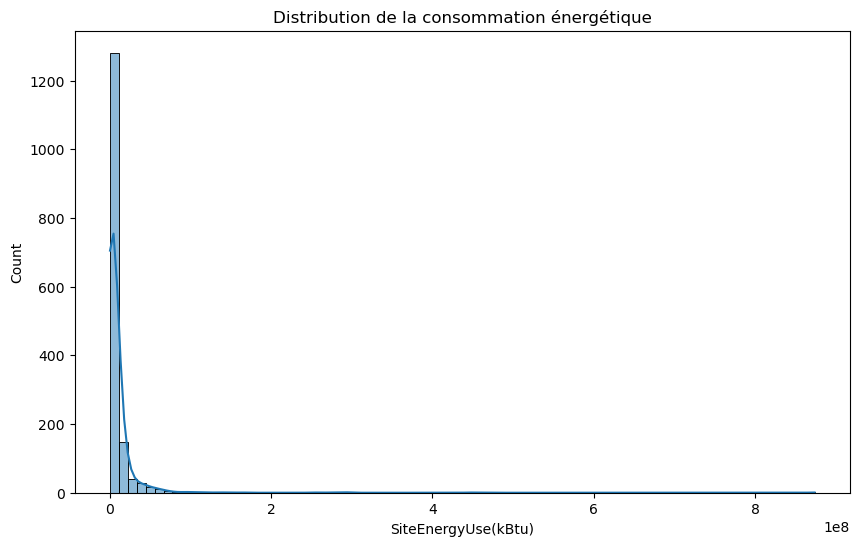

In [47]:
plt.figure(figsize=(10,6))

sns.histplot(y, kde=True)

plt.title("Distribution de la consommation énergétique")

plt.show()

# Heatmap corrélation

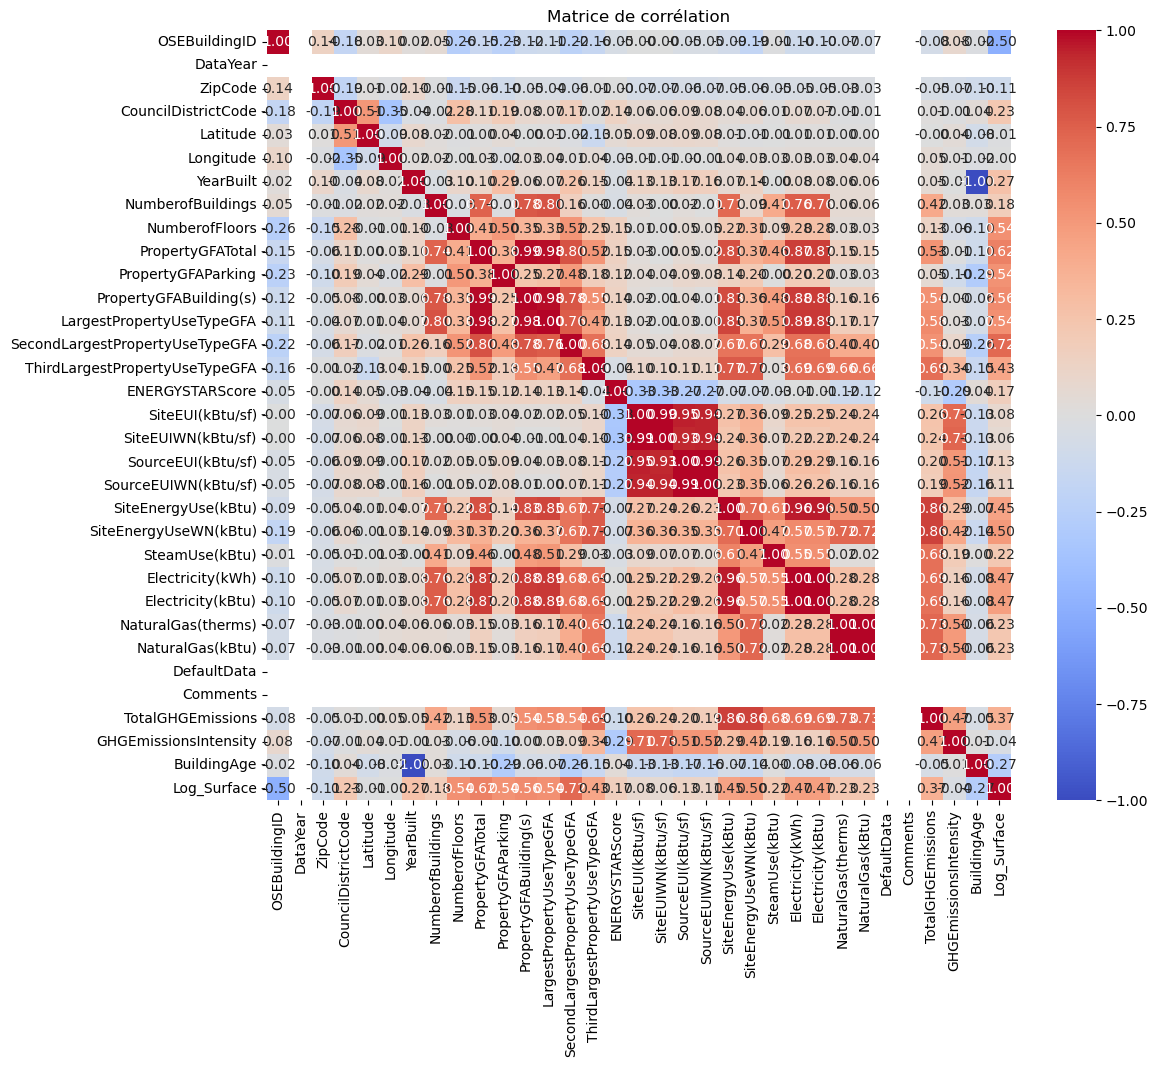

In [48]:
corr_matrix = building_consumption.corr(numeric_only=True)

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation")

plt.show()

# Préprocessing

In [49]:
categorical_cols = X.select_dtypes(include=["object", "string"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_transformer,
        numeric_cols
    ),
    (
        "cat",
        categorical_transformer,
        categorical_cols
    )
])

# Split train test

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [52]:
display(X_test)

,YearBuilt,BuildingAge,NumberofFloors,Log_Surface,PropertyGFATotal,LargestPropertyUseTypeGFA,PropertyGFABuilding(s),BuildingType,PrimaryPropertyType,City,State
35,1992,24,3,13.111982,494835,757027.0,494835,Campus,Mixed Use Property,Seattle,WA
3278,1953,63,0,12.025701,166991,166991.0,166991,NonResidential,Residence Hall,Seattle,WA
2193,1954,62,1,10.645449,42000,38000.0,42000,NonResidential,Warehouse,Seattle,WA
2245,1954,62,2,9.994288,21900,21900.0,21900,NonResidential,Retail Store,Seattle,WA
589,1952,64,2,11.658488,115668,101752.0,115668,NonResidential,Warehouse,Seattle,WA
...,...,...,...,...,...,...,...,...,...,...,...
2333,1956,60,1,10.596260,39984,31184.0,39984,NonResidential,Warehouse,Seattle,WA
1970,1985,31,1,10.047631,23100,11550.0,23100,Nonresidential COS,Mixed Use Property,Seattle,WA
2739,1954,62,1,9.981605,21624,21624.0,21624,NonResidential,Worship Facility,Seattle,WA
545,2006,10,6,11.873672,143439,119570.0,143439,NonResidential,Other,Seattle,WA


# Modèles

In [53]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "SVR": SVR()
}

# Validation croisée

In [54]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=5,
        scoring=[
            "r2",
            "neg_mean_absolute_error",
            "neg_root_mean_squared_error"
        ]
    )

    results.append({
        "Model": name,
        "R2_mean": scores["test_r2"].mean(),
        "MAE_mean": -scores["test_neg_mean_absolute_error"].mean(),
        "RMSE_mean": -scores["test_neg_root_mean_squared_error"].mean()
    })

results_df = pd.DataFrame(results)

print(results_df)

              Model   R2_mean      MAE_mean     RMSE_mean
0  LinearRegression  0.556413  5.778642e+06  1.414227e+07
1      RandomForest  0.547086  5.014388e+06  1.957708e+07
2               SVR -0.064387  7.826094e+06  2.707623e+07


# GridSearch RandomForest

In [55]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(random_state=42)
    )
])

param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [10, 20],
    "model__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print(grid.best_params_)

{'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 100}


# Évaluation finale

In [58]:
y_pred = best_model.predict(X_test)

print("R2 :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", root_mean_squared_error(y_test, y_pred))

R2 : 0.2641368339266622
MAE : 7347418.631611049
RMSE : 49509917.18974646


# Feature importance

In [59]:
rf_model = best_model.named_steps["model"]

feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(importance_df.head(10))

                                        feature  importance
5                num__LargestPropertyUseTypeGFA    0.239534
13            cat__PrimaryPropertyType_Hospital    0.237867
6                   num__PropertyGFABuilding(s)    0.206489
3                              num__Log_Surface    0.105219
4                         num__PropertyGFATotal    0.100961
2                           num__NumberofFloors    0.033081
21               cat__PrimaryPropertyType_Other    0.017648
0                                num__YearBuilt    0.009482
20  cat__PrimaryPropertyType_Mixed Use Property    0.009218
1                              num__BuildingAge    0.008687


# Sauvegarde du modèle

In [60]:
joblib.dump(best_model, "model.pkl")

['model.pkl']